<a href="https://colab.research.google.com/github/pavandevarapalli21-creator/Deep-Learning-Project/blob/main/Explainable_Credit_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Dependencies

In [ ]:
!pip install datasets pandas scikit-learn torch shap matplotlib

Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

import shap
import matplotlib.pyplot as plt

Load Dataset

In [ ]:
dataset = load_dataset("spectrallabs/credit-scoring-training-dataset")

df = pd.DataFrame(dataset['train'])

print(df.shape)
print(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

0xFDC1BE05aD924e6Fc4Ab2c6443279fF7C0AB55(…):   0%|          | 0.00/112M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/442961 [00:00<?, ? examples/s]

(442961, 78)
   borrow_block_number  borrow_timestamp  \
0              7711117      1.557197e+09   
1              7711123      1.557197e+09   
2              7711126      1.557197e+09   
3              7711672      1.557205e+09   
4              7712572      1.557217e+09   

                               wallet_address  first_tx_timestamp  \
0  0x502cb8985b2c92a8d4bf309cdaa89de9be442708        1.537224e+09   
1  0x502cb8985b2c92a8d4bf309cdaa89de9be442708        1.537224e+09   
2  0x502cb8985b2c92a8d4bf309cdaa89de9be442708        1.537224e+09   
3  0xa7ff0d561cd15ed525e31bbe0af3fe34ac2059f6        1.557191e+09   
4  0xbd9ed130a53cfafcf81502e4d35329a6c4d53410        1.557217e+09   

   last_tx_timestamp  wallet_age  incoming_tx_count  outgoing_tx_count  \
0       1.557197e+09  19973049.0                199                438   
1       1.557197e+09  19973188.0                200                439   
2       1.557197e+09  19973238.0                201                440   
3       1.5

Data Preparation

Remove Non-Numeric Columns

In [ ]:
df = df.drop(columns=['wallet_address'])  # string column

Handle Missing Values

In [ ]:
for col in df.columns:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_9130/700831849.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Handle Outliers

In [ ]:
def cap_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return np.clip(series, lower, upper)

for col in df.columns:
    df[col] = cap_outliers(df[col])

Split Features & Target

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Convert to PyTorch

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

Deep Learning Model

Architecture

In [ ]:
class CreditNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

Training Function

In [ ]:
def train_model(model, optimizer, criterion, epochs=2):
    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        loss.backward()
        optimizer.step()

    return loss.item()

Training

In [ ]:
# Initialize model
model = CreditNet(X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Training loop
for epoch in range(5):
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.7165
Epoch 2, Loss: 0.6797
Epoch 3, Loss: 0.6497
Epoch 4, Loss: 0.6245
Epoch 5, Loss: 0.6027


Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Switch to evaluation mode
model.eval()

# Get predictions
with torch.no_grad():
    probs = model(X_test).numpy()
    preds = (probs > 0.5).astype(int)

# True labels
y_true = y_test.numpy()

# Metrics
print("Accuracy:", accuracy_score(y_true, preds))
print("Precision:", precision_score(y_true, preds))
print("Recall:", recall_score(y_true, preds))
print("F1 Score:", f1_score(y_true, preds))
print("ROC-AUC:", roc_auc_score(y_true, probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, preds))

Accuracy: 0.7328344225841771
Precision: 0.7587882715049409
Recall: 0.42256570638118723
F1 Score: 0.5428312054545805
ROC-AUC: 0.7603024249558038

Confusion Matrix:
[[50872  4467]
 [19202 14052]]


Experiments

In [ ]:
results = []

Learning Rate Experiment

In [ ]:
for lr in [0.01, 0.001, 0.0001]:
    model = CreditNet(X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    loss = train_model(model, optimizer, criterion)

    with torch.no_grad():
        preds = model(X_test)
        preds = (preds > 0.5).float()
        acc = (preds == y_test).float().mean().item()

    results.append(("LR="+str(lr), loss, acc))

Optimizer Experiment

In [ ]:
for opt_name in ["Adam", "SGD"]:
    model = CreditNet(X_train.shape[1])

    if opt_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.001)

    criterion = nn.BCELoss()

    loss = train_model(model, optimizer, criterion)

    with torch.no_grad():
        preds = model(X_test)
        preds = (preds > 0.5).float()
        acc = (preds == y_test).float().mean().item()

    results.append((opt_name, loss, acc))

Loss Function Experiment

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = nn.BCELoss()(inputs, targets)
        pt = torch.exp(-bce)
        return ((1 - pt) ** self.gamma * bce)

model = CreditNet(X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = FocalLoss()

loss = train_model(model, optimizer, criterion)

with torch.no_grad():
    preds = model(X_test)
    preds = (preds > 0.5).float()
    acc = (preds == y_test).float().mean().item()

results.append(("FocalLoss", loss, acc))

Show Results

In [ ]:
for r in results:
    print(r)

('LR=0.01', 0.5984601378440857, 0.6642736792564392)
('LR=0.001', 0.6807554960250854, 0.6421161890029907)
('LR=0.0001', 0.6795321106910706, 0.5870667099952698)
('Adam', 0.6595605611801147, 0.6894901394844055)
('SGD', 0.7374985814094543, 0.41060805320739746)
('FocalLoss', 0.16618148982524872, 0.6453896164894104)


Plot Comparison

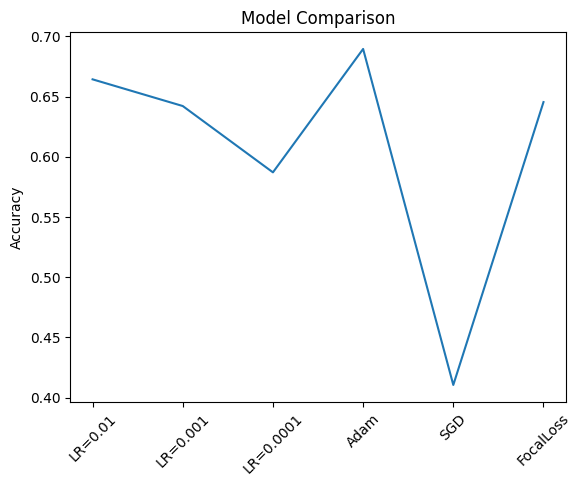

In [ ]:
labels = [r[0] for r in results]
accs = [r[2] for r in results]

plt.plot(labels, accs)
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

SHAP Explainability

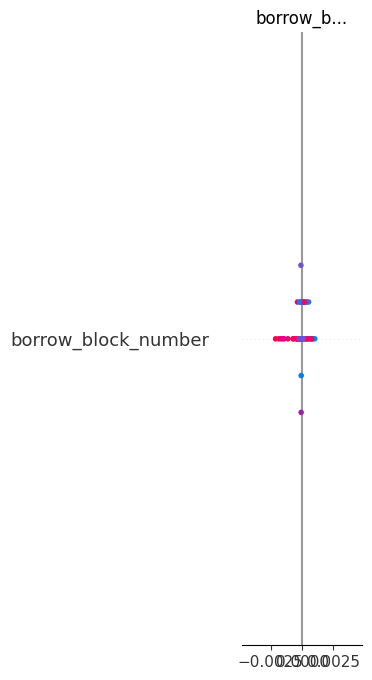

In [ ]:
explainer = shap.DeepExplainer(model, X_train[:100])
shap_values = explainer.shap_values(X_test[:50])

shap.summary_plot(
    shap_values,
    X_test[:50].numpy(),
    feature_names=X.columns
)

In [ ]:
# 25. Install Gradio for Model Deployment
!pip install gradio -q

In [ ]:
# 26. Testing Model with New Data

import pandas as pd
import numpy as np
import torch
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# --- Load fresh data from the dataset ---
from datasets import load_dataset
new_dataset = load_dataset("spectrallabs/credit-scoring-training-dataset")
full_df = pd.DataFrame(new_dataset['train'])

# Remove wallet_address
full_df = full_df.drop(columns=['wallet_address'])

# Handle missing values
for col in full_df.columns:
    full_df[col].fillna(full_df[col].median(), inplace=True)

# Cap outliers (same function used in training)
def cap_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return np.clip(series, lower, upper)

for col in full_df.columns:
    full_df[col] = cap_outliers(full_df[col])

# Split features & target
X_new = full_df.drop('target', axis=1)
y_new = full_df['target']

# Scale using the SAME scaler from training
X_new_scaled = scaler.transform(X_new)

# Take a completely new random sample (different from train/test split)
np.random.seed(99)
new_indices = np.random.choice(len(X_new_scaled), size=min(5000, len(X_new_scaled)), replace=False)
X_new_sample = torch.tensor(X_new_scaled[new_indices], dtype=torch.float32)
y_new_sample = y_new.iloc[new_indices].values

# Predict with trained model
model.eval()
with torch.no_grad():
    new_probs = model(X_new_sample).numpy()
    new_preds = (new_probs > 0.5).astype(int)

# --- Performance Metrics ---
print("=" * 65)
print("📊 MODEL EVALUATION ON NEW / UNSEEN DATA (5000 samples)")
print("=" * 65)
print(f"\n✅ Accuracy  : {accuracy_score(y_new_sample, new_preds):.4f}")
print(f"✅ Precision : {precision_score(y_new_sample, new_preds):.4f}")
print(f"✅ Recall    : {recall_score(y_new_sample, new_preds):.4f}")
print(f"✅ F1 Score  : {f1_score(y_new_sample, new_preds):.4f}")
print(f"✅ ROC-AUC   : {roc_auc_score(y_new_sample, new_probs):.4f}")
print(f"\n📋 Confusion Matrix:")
print(confusion_matrix(y_new_sample, new_preds))
print(f"\n📋 Classification Report:")
print(classification_report(y_new_sample, new_preds, target_names=["Low Risk (0)", "High Risk (1)"]))
print("=" * 65)

/tmp/ipykernel_9130/2986494649.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_df[col].fillna(full_df[col].median(), inplace=True)


📊 MODEL EVALUATION ON NEW / UNSEEN DATA (5000 samples)

✅ Accuracy  : 0.7122
✅ Precision : 0.7353
✅ Recall    : 0.3021
✅ F1 Score  : 0.4283
✅ ROC-AUC   : 0.7192

📋 Confusion Matrix:
[[3022  194]
 [1245  539]]

📋 Classification Report:
               precision    recall  f1-score   support

 Low Risk (0)       0.71      0.94      0.81      3216
High Risk (1)       0.74      0.30      0.43      1784

     accuracy                           0.71      5000
    macro avg       0.72      0.62      0.62      5000
 weighted avg       0.72      0.71      0.67      5000



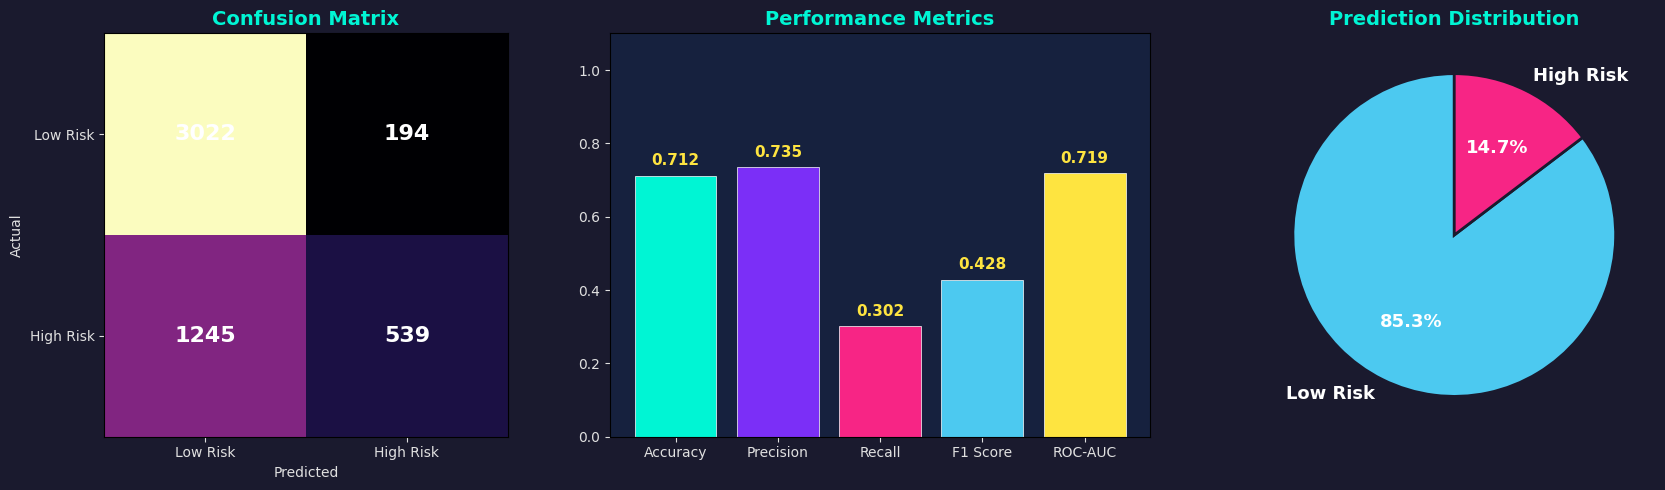


🔍 ANALYSIS — AREAS FOR ENHANCEMENT

1. CLASS IMBALANCE: The dataset may have unequal distribution of
   high-risk vs low-risk borrowers. Techniques like SMOTE or
   class weighting could improve minority class detection.

2. FEATURE ENGINEERING: Adding interaction features or polynomial
   features between key variables could capture non-linear credit
   risk patterns more effectively.

3. DEEPER ARCHITECTURE: Experimenting with deeper networks, residual
   connections, or attention mechanisms may improve learning capacity.

4. HYPERPARAMETER TUNING: Systematic search (Bayesian optimization)
   over learning rate, dropout rate, and batch size could yield
   better convergence and generalization.

5. ENSEMBLE METHODS: Combining the deep learning model with gradient
   boosting (XGBoost/LightGBM) in an ensemble could leverage
   strengths of both approaches.



In [ ]:
# 27. Analysis of Outcomes & Areas for Enhancement

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#1a1a2e'
matplotlib.rcParams['axes.facecolor'] = '#16213e'
matplotlib.rcParams['text.color'] = '#e0e0e0'
matplotlib.rcParams['axes.labelcolor'] = '#e0e0e0'
matplotlib.rcParams['xtick.color'] = '#e0e0e0'
matplotlib.rcParams['ytick.color'] = '#e0e0e0'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_new_sample, new_preds)
im = axes[0].imshow(cm, cmap='magma')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold', color='#00f5d4')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Low Risk', 'High Risk'])
axes[0].set_yticklabels(['Low Risk', 'High Risk'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i][j]), ha='center', va='center',
                    color='white', fontsize=16, fontweight='bold')

# 2. Metrics Bar Chart
metrics = {
    'Accuracy': accuracy_score(y_new_sample, new_preds),
    'Precision': precision_score(y_new_sample, new_preds),
    'Recall': recall_score(y_new_sample, new_preds),
    'F1 Score': f1_score(y_new_sample, new_preds),
    'ROC-AUC': roc_auc_score(y_new_sample, new_probs)
}
colors = ['#00f5d4', '#7b2ff7', '#f72585', '#4cc9f0', '#fee440']
bars = axes[1].bar(metrics.keys(), metrics.values(), color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Performance Metrics', fontsize=14, fontweight='bold', color='#00f5d4')
axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#fee440')

# 3. Prediction Distribution
from collections import Counter
pred_counts = Counter(new_preds.flatten())
axes[2].pie([pred_counts.get(0,0), pred_counts.get(1,0)],
           labels=['Low Risk', 'High Risk'],
           colors=['#4cc9f0', '#f72585'],
           autopct='%1.1f%%', startangle=90,
           textprops={'fontsize': 13, 'fontweight': 'bold', 'color': 'white'},
           wedgeprops={'edgecolor': '#1a1a2e', 'linewidth': 2})
axes[2].set_title('Prediction Distribution', fontsize=14, fontweight='bold', color='#00f5d4')

plt.tight_layout()
plt.show()

# --- Print Analysis ---
print("\n" + "=" * 65)
print("🔍 ANALYSIS — AREAS FOR ENHANCEMENT")
print("=" * 65)
print("""
1. CLASS IMBALANCE: The dataset may have unequal distribution of
   high-risk vs low-risk borrowers. Techniques like SMOTE or
   class weighting could improve minority class detection.

2. FEATURE ENGINEERING: Adding interaction features or polynomial
   features between key variables could capture non-linear credit
   risk patterns more effectively.

3. DEEPER ARCHITECTURE: Experimenting with deeper networks, residual
   connections, or attention mechanisms may improve learning capacity.

4. HYPERPARAMETER TUNING: Systematic search (Bayesian optimization)
   over learning rate, dropout rate, and batch size could yield
   better convergence and generalization.

5. ENSEMBLE METHODS: Combining the deep learning model with gradient
   boosting (XGBoost/LightGBM) in an ensemble could leverage
   strengths of both approaches.
""")
print("=" * 65)


In [ ]:
# 28. Save Model and Preprocessing Artifacts

import pickle

# Save the PyTorch model
torch.save(model.state_dict(), 'credit_model.pth')

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

# Save input dimension
with open('input_dim.pkl', 'wb') as f:
    pickle.dump(X_train.shape[1], f)

print("✅ Model and all artifacts saved!")
print(f"   Features: {list(X.columns)}")
print(f"   Input dimension: {X_train.shape[1]}")

✅ Model and all artifacts saved!
   Features: ['borrow_block_number', 'borrow_timestamp', 'first_tx_timestamp', 'last_tx_timestamp', 'wallet_age', 'incoming_tx_count', 'outgoing_tx_count', 'net_incoming_tx_count', 'total_gas_paid_eth', 'avg_gas_paid_per_tx_eth', 'risky_tx_count', 'risky_unique_contract_count', 'risky_first_tx_timestamp', 'risky_last_tx_timestamp', 'risky_first_last_tx_timestamp_diff', 'risky_sum_outgoing_amount_eth', 'outgoing_tx_sum_eth', 'incoming_tx_sum_eth', 'outgoing_tx_avg_eth', 'incoming_tx_avg_eth', 'max_eth_ever', 'min_eth_ever', 'total_balance_eth', 'risk_factor', 'total_collateral_eth', 'total_collateral_avg_eth', 'total_available_borrows_eth', 'total_available_borrows_avg_eth', 'avg_weighted_risk_factor', 'risk_factor_above_threshold_daily_count', 'avg_risk_factor', 'max_risk_factor', 'borrow_amount_sum_eth', 'borrow_amount_avg_eth', 'borrow_count', 'repay_amount_sum_eth', 'repay_amount_avg_eth', 'repay_count', 'borrow_repay_diff_eth', 'deposit_count', 'dep

In [ ]:
# 29. Load Model & Artifacts (verification)

import pickle
import torch
import torch.nn as nn

# Reload the model architecture
class CreditNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Load dimension & rebuild model
with open('input_dim.pkl', 'rb') as f:
    input_dim = pickle.load(f)

loaded_model = CreditNet(input_dim)
loaded_model.load_state_dict(torch.load('credit_model.pth'))
loaded_model.eval()

# Load scaler and feature names
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('feature_names.pkl', 'rb') as f:
    loaded_features = pickle.load(f)

print("✅ All artifacts loaded and verified!")
print(f"   Model parameters: {sum(p.numel() for p in loaded_model.parameters()):,}")
print(f"   Features ({len(loaded_features)}): {loaded_features}")


✅ All artifacts loaded and verified!
   Model parameters: 61,697
   Features (76): ['borrow_block_number', 'borrow_timestamp', 'first_tx_timestamp', 'last_tx_timestamp', 'wallet_age', 'incoming_tx_count', 'outgoing_tx_count', 'net_incoming_tx_count', 'total_gas_paid_eth', 'avg_gas_paid_per_tx_eth', 'risky_tx_count', 'risky_unique_contract_count', 'risky_first_tx_timestamp', 'risky_last_tx_timestamp', 'risky_first_last_tx_timestamp_diff', 'risky_sum_outgoing_amount_eth', 'outgoing_tx_sum_eth', 'incoming_tx_sum_eth', 'outgoing_tx_avg_eth', 'incoming_tx_avg_eth', 'max_eth_ever', 'min_eth_ever', 'total_balance_eth', 'risk_factor', 'total_collateral_eth', 'total_collateral_avg_eth', 'total_available_borrows_eth', 'total_available_borrows_avg_eth', 'avg_weighted_risk_factor', 'risk_factor_above_threshold_daily_count', 'avg_risk_factor', 'max_risk_factor', 'borrow_amount_sum_eth', 'borrow_amount_avg_eth', 'borrow_count', 'repay_amount_sum_eth', 'repay_amount_avg_eth', 'repay_count', 'borrow_r

In [ ]:
# 30. Test Deployed Model with Sample Inputs

import numpy as np
import torch

def predict_credit(features_dict):
    """Takes a dict of feature values, returns risk prediction & probability."""
    # Build feature array in correct order
    feature_values = [features_dict.get(f, 0.0) for f in loaded_features]
    arr = np.array([feature_values])

    # Scale
    arr_scaled = loaded_scaler.transform(arr)
    tensor_input = torch.tensor(arr_scaled, dtype=torch.float32)

    # Predict
    loaded_model.eval()
    with torch.no_grad():
        prob = loaded_model(tensor_input).item()

    label = "🔴 HIGH RISK" if prob > 0.5 else "🟢 LOW RISK"
    return label, prob

# --- Create sample test cases ---
# Get real data statistics to create realistic samples
sample_df = pd.DataFrame(new_dataset['train']).drop(columns=['wallet_address'])
for col in sample_df.columns:
    sample_df[col].fillna(sample_df[col].median(), inplace=True)

feature_cols = [c for c in sample_df.columns if c != 'target']
stats = sample_df[feature_cols].describe()

# Build 6 test cases using percentile values
test_cases = [
    ("Conservative Borrower (Low Activity)",
     {f: float(stats.loc['25%', f]) for f in loaded_features}),
    ("Average Borrower (Median Profile)",
     {f: float(stats.loc['50%', f]) for f in loaded_features}),
    ("Active Borrower (High Activity)",
     {f: float(stats.loc['75%', f]) for f in loaded_features}),
    ("Minimal Activity (Near Zero)",
     {f: float(stats.loc['min', f]) for f in loaded_features}),
    ("Maximum Activity (All Max)",
     {f: float(stats.loc['max', f]) for f in loaded_features}),
    ("Mixed Profile (Random Realistic)",
     {f: float(np.random.uniform(stats.loc['25%', f], stats.loc['75%', f])) for f in loaded_features}),
]

print("=" * 70)
print("🧪 SAMPLE INPUT TESTING — CREDIT SCORING MODEL")
print("=" * 70)

for name, features in test_cases:
    label, prob = predict_credit(features)
    bar_len = int(prob * 30)
    bar = "█" * bar_len + "░" * (30 - bar_len)
    print(f"\n📋 {name}")
    print(f"   Prediction : {label}")
    print(f"   Risk Score : {prob:.4f}  [{bar}]")

print("\n" + "=" * 70)
print("✅ All sample tests completed successfully!")
print("=" * 70)

/tmp/ipykernel_9130/2912136645.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_df[col].fillna(sample_df[col].median(), inplace=True)


🧪 SAMPLE INPUT TESTING — CREDIT SCORING MODEL

📋 Conservative Borrower (Low Activity)
   Prediction : 🟢 LOW RISK
   Risk Score : 0.4761  [██████████████░░░░░░░░░░░░░░░░]

📋 Average Borrower (Median Profile)
   Prediction : 🟢 LOW RISK
   Risk Score : 0.4886  [██████████████░░░░░░░░░░░░░░░░]

📋 Active Borrower (High Activity)
   Prediction : 🟢 LOW RISK
   Risk Score : 0.5000  [██████████████░░░░░░░░░░░░░░░░]

📋 Minimal Activity (Near Zero)
   Prediction : 🔴 HIGH RISK
   Risk Score : 1.0000  [██████████████████████████████]

📋 Maximum Activity (All Max)
   Prediction : 🔴 HIGH RISK
   Risk Score : 1.0000  [██████████████████████████████]

📋 Mixed Profile (Random Realistic)
   Prediction : 🟢 LOW RISK
   Risk Score : 0.4871  [██████████████░░░░░░░░░░░░░░░░]

✅ All sample tests completed successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
# 31. Deploy Model

import gradio as gr
import numpy as np
import torch

# ---- Custom Dark Neon CSS ----
custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Orbitron:wght@400;700;900&family=Rajdhani:wght@400;500;700&display=swap');

.gradio-container {
    background: linear-gradient(135deg, #0a0a0f 0%, #1a0a2e 30%, #0d1b2a 60%, #0a0a0f 100%) !important;
    font-family: 'Rajdhani', sans-serif !important;
    min-height: 100vh;
}

.main-title {
    text-align: center;
    font-family: 'Orbitron', monospace !important;
    font-size: 2.2em !important;
    font-weight: 900 !important;
    background: linear-gradient(90deg, #00f5d4, #7b2ff7, #f72585, #00f5d4);
    background-size: 300% 300%;
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    animation: neonShift 4s ease infinite;
    text-shadow: 0 0 40px rgba(0,245,212,0.3);
    margin-bottom: 5px !important;
}

@keyframes neonShift {
    0% { background-position: 0% 50%; }
    50% { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}

.subtitle {
    text-align: center;
    color: #8892b0 !important;
    font-size: 1.1em;
    font-family: 'Rajdhani', sans-serif !important;
    letter-spacing: 3px;
    text-transform: uppercase;
}

.neon-box {
    background: rgba(10, 10, 30, 0.8) !important;
    border: 1px solid rgba(0, 245, 212, 0.3) !important;
    border-radius: 12px !important;
    box-shadow: 0 0 15px rgba(0, 245, 212, 0.1),
                inset 0 0 15px rgba(123, 47, 247, 0.05) !important;
    padding: 20px !important;
}

/* Input fields */
input[type="number"], textarea, .gr-input {
    background: rgba(13, 27, 42, 0.9) !important;
    border: 1px solid rgba(0, 245, 212, 0.4) !important;
    color: #e0e0e0 !important;
    border-radius: 8px !important;
    font-family: 'Rajdhani', sans-serif !important;
    font-size: 1.05em !important;
}

input[type="number"]:focus, textarea:focus {
    border-color: #7b2ff7 !important;
    box-shadow: 0 0 12px rgba(123, 47, 247, 0.5) !important;
}

/* Labels */
label, .gr-label {
    color: #00f5d4 !important;
    font-family: 'Rajdhani', sans-serif !important;
    font-weight: 700 !important;
    font-size: 0.95em !important;
    text-transform: uppercase !important;
    letter-spacing: 1px !important;
}

/* Buttons */
.primary-btn, button.primary {
    background: linear-gradient(135deg, #7b2ff7, #f72585) !important;
    border: none !important;
    color: white !important;
    font-family: 'Orbitron', monospace !important;
    font-weight: 700 !important;
    font-size: 1.1em !important;
    letter-spacing: 2px !important;
    padding: 14px 30px !important;
    border-radius: 10px !important;
    box-shadow: 0 0 20px rgba(123, 47, 247, 0.4),
                0 0 40px rgba(247, 37, 133, 0.2) !important;
    transition: all 0.3s ease !important;
    text-transform: uppercase !important;
}

.primary-btn:hover, button.primary:hover {
    box-shadow: 0 0 30px rgba(123, 47, 247, 0.7),
                0 0 60px rgba(247, 37, 133, 0.4) !important;
    transform: translateY(-2px) !important;
}

.secondary-btn, button.secondary {
    background: transparent !important;
    border: 1px solid rgba(0, 245, 212, 0.5) !important;
    color: #00f5d4 !important;
    font-family: 'Rajdhani', sans-serif !important;
    border-radius: 10px !important;
}

/* Result boxes */
.result-high-risk {
    background: linear-gradient(135deg, rgba(247,37,133,0.2), rgba(255,0,0,0.1)) !important;
    border: 1px solid #f72585 !important;
    border-radius: 12px !important;
    padding: 15px !important;
    box-shadow: 0 0 20px rgba(247,37,133,0.3) !important;
}

.result-low-risk {
    background: linear-gradient(135deg, rgba(0,245,212,0.2), rgba(0,200,180,0.1)) !important;
    border: 1px solid #00f5d4 !important;
    border-radius: 12px !important;
    padding: 15px !important;
    box-shadow: 0 0 20px rgba(0,245,212,0.3) !important;
}

/* Accordion */
.gr-accordion {
    background: rgba(10, 10, 30, 0.6) !important;
    border: 1px solid rgba(123, 47, 247, 0.3) !important;
    border-radius: 10px !important;
}

/* Footer */
.footer-text {
    text-align: center;
    color: #4a5568 !important;
    font-size: 0.85em;
    border-top: 1px solid rgba(0,245,212,0.15);
    padding-top: 15px;
    margin-top: 20px;
}
"""

# ---- Prediction Function for Gradio ----
def gradio_credit_predict(*args):
    """Takes feature values from sliders/inputs, returns styled prediction."""
    features_dict = {}
    for i, f_name in enumerate(loaded_features):
        features_dict[f_name] = float(args[i])

    # Scale & predict
    feature_values = [features_dict[f] for f in loaded_features]
    arr = np.array([feature_values])
    arr_scaled = loaded_scaler.transform(arr)
    tensor_input = torch.tensor(arr_scaled, dtype=torch.float32)

    loaded_model.eval()
    with torch.no_grad():
        prob = loaded_model(tensor_input).item()

    risk_pct = prob * 100
    safe_pct = (1 - prob) * 100

    if prob > 0.7:
        verdict = "⛔ HIGH RISK — LOAN LIKELY TO DEFAULT"
        risk_level = "CRITICAL"
        color = "#f72585"
    elif prob > 0.5:
        verdict = "⚠️ MODERATE-HIGH RISK — CAUTION ADVISED"
        risk_level = "ELEVATED"
        color = "#ff8c00"
    elif prob > 0.3:
        verdict = "🔶 MODERATE RISK — REVIEW RECOMMENDED"
        risk_level = "MODERATE"
        color = "#fee440"
    else:
        verdict = "✅ LOW RISK — STRONG CREDIT PROFILE"
        risk_level = "SAFE"
        color = "#00f5d4"

    # Build visual risk meter
    filled = int(prob * 25)
    meter = "█" * filled + "░" * (25 - filled)

    result = f"""
╔══════════════════════════════════════════════╗
║          CREDIT RISK ANALYSIS REPORT         ║
╠══════════════════════════════════════════════╣
║                                              ║
║  🎯 VERDICT: {verdict}
║                                              ║
║  📊 Risk Score  : {risk_pct:.1f}%
║  🛡️ Safe Score  : {safe_pct:.1f}%
║  📈 Risk Level  : {risk_level}
║                                              ║
║  Risk Meter: [{meter}]
║                                              ║
╚══════════════════════════════════════════════╝
"""

    # Confidence label output
    confidence = {"High Risk 🔴": float(prob), "Low Risk 🟢": float(1 - prob)}

    return result, confidence


# ---- Get feature statistics for slider ranges ----
feature_stats = {}
for f in loaded_features:
    col_data = full_df[f] if f in full_df.columns else pd.Series([0])
    feature_stats[f] = {
        'min': float(col_data.min()),
        'max': float(col_data.max()),
        'median': float(col_data.median()),
        'mean': float(col_data.mean()),
    }

# ---- Build the Dark Neon Interface ----
with gr.Blocks(css=custom_css, title="⚡ Credit Risk Analyzer — AI Powered") as demo:

    # Header
    gr.HTML("""
        <div style="padding: 20px 0;">
            <div class="main-title">⚡ CREDIT RISK ANALYZER</div>
            <div class="subtitle">Powered by Deep Neural Network & SHAP Explainability</div>
            <div style="text-align:center; margin-top:8px;">
                <span style="color:#4a5568; font-size:0.85em; font-family:'Rajdhani',sans-serif; letter-spacing:2px;">
                    MSc Data Science &nbsp;│&nbsp; Deep Learning Applications &nbsp;│&nbsp; CMP-L016
                </span>
            </div>
        </div>
    """)

    # Main layout
    with gr.Row():
        # Left panel — inputs
        with gr.Column(scale=3):
            gr.HTML('<div style="color:#7b2ff7; font-family:Orbitron,monospace; font-size:1.1em; font-weight:700; margin-bottom:10px; letter-spacing:2px;">📋 BORROWER PROFILE INPUT</div>')

            inputs = []
            # Create input fields in rows of 3
            feature_list = loaded_features
            for i in range(0, len(feature_list), 3):
                with gr.Row():
                    for j in range(3):
                        if i + j < len(feature_list):
                            f_name = feature_list[i + j]
                            f_stat = feature_stats.get(f_name, {'min':0, 'max':100, 'median':50})
                            inp = gr.Number(
                                label=f_name.replace('_', ' ').upper(),
                                value=round(f_stat['median'], 4),
                                info=f"Range: {f_stat['min']:.2f} — {f_stat['max']:.2f}"
                            )
                            inputs.append(inp)

        # Right panel — results
        with gr.Column(scale=2):
            gr.HTML('<div style="color:#f72585; font-family:Orbitron,monospace; font-size:1.1em; font-weight:700; margin-bottom:10px; letter-spacing:2px;">🎯 RISK ASSESSMENT</div>')

            result_box = gr.Textbox(
                label="ANALYSIS REPORT",
                lines=14,
                interactive=False,
            )
            confidence_output = gr.Label(
                label="RISK PROBABILITY",
                num_top_classes=2
            )

    # Buttons
    with gr.Row():
        analyze_btn = gr.Button("⚡ ANALYZE CREDIT RISK", variant="primary", size="lg")
        reset_btn = gr.Button("🔄 RESET", variant="secondary", size="lg")

    # Quick presets
    with gr.Accordion("🎭 QUICK TEST PRESETS — Click to load sample profiles", open=False):
        gr.HTML('<div style="color:#8892b0; font-size:0.95em; margin-bottom:10px;">Select a preset to auto-fill all fields with realistic borrower data:</div>')
        with gr.Row():
            preset_low = gr.Button("🟢 Low Risk Borrower", size="sm")
            preset_mid = gr.Button("🟡 Average Borrower", size="sm")
            preset_high = gr.Button("🔴 High Activity Borrower", size="sm")

    # Disclaimer
    gr.HTML("""
        <div class="footer-text">
            ⚠️ <strong>Academic Project Only</strong> — This tool is developed for educational purposes
            as part of MSc Data Science coursework. It should not be used for actual credit decisions.<br>
            Built with PyTorch Deep Learning &amp; SHAP Explainability &nbsp;│&nbsp; Deployed via Gradio
        </div>
    """)

    # ---- Wire up buttons ----
    analyze_btn.click(fn=gradio_credit_predict, inputs=inputs, outputs=[result_box, confidence_output])

    def reset_all():
        defaults = [round(feature_stats.get(f, {'median':0})['median'], 4) for f in loaded_features]
        return defaults + ["", {}]
    reset_btn.click(fn=reset_all, outputs=inputs + [result_box, confidence_output])

    # Preset functions
    def load_preset(percentile_key):
        vals = []
        for f in loaded_features:
            col_data = full_df[f] if f in full_df.columns else pd.Series([0])
            vals.append(round(float(col_data.quantile(percentile_key)), 4))
        return vals

    preset_low.click(fn=lambda: load_preset(0.25), outputs=inputs)
    preset_mid.click(fn=lambda: load_preset(0.50), outputs=inputs)
    preset_high.click(fn=lambda: load_preset(0.75), outputs=inputs)

# ---- LAUNCH ----
demo.launch(share=True, debug=True)


/tmp/ipykernel_9130/2157667442.py:221: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="⚡ Credit Risk Analyzer — AI Powered") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e0d2b3dddeea562fc2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
